# 04_10. Highly variable isoform selection + dimensionality reduction

An alternative to 04_09 that selects **highly variable isoform features directly** on the isoform-fraction matrix, rather than selecting highly variable *diversity genes* by the variance of a per-cell scalar entropy. The selector corrects the p(1−p) mean–variance coupling of bounded fractions by scoring each isoform's **overdispersion relative to a binomial sampling null**, requires a minimum detection, and is batch-aware (reproducible across tissues). PCA + UMAP are then computed on the selected isoforms and compared to the 04_09 embedding.

In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse, csr_matrix, csc_matrix as _csc_matrix
import warnings, os, sys, gc
warnings.filterwarnings('ignore')
sc.settings.set_figure_params(dpi=150, facecolor='white', frameon=True, figsize=(5, 5))
gc.enable()

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP


In [2]:
# preferred plot formatting
import matplotlib
import matplotlib.legend as _mlegend
import matplotlib.pyplot as plt

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0

plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.labelspacing": 0.1,
    "legend.borderpad": 0.3,
    "legend.handletextpad": 0.2,
    "legend.title_fontsize": 6,
    "figure.titlesize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD,
    "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
    "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Legend-title weight has no rcParam -> make every legend title bold by default.
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True


In [3]:
# Load the pre-computed isoform-fraction AnnData (>=10 cells, genes with >=2 isoforms)
adata = sc.read_h5ad(f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_ensemblids_bc_anndata_preprocessed_with_isofrac.h5ad")
print(f"Loaded: {adata.shape[0]} cells x {adata.shape[1]} isoforms")
gene_col = "associated_gene" if "associated_gene" in adata.var.columns else "gene_name"
print(f"Using gene column: {gene_col}")
adata

Loaded: 203311 cells x 478192 isoforms
Using gene column: gene_name


AnnData object with n_obs × n_vars = 203311 × 478192
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'tube_id', 'n_counts', 'donor', 'tissue', 'tube_label', 'LR_library_id', 'SR_sample_id', 'popv_prediction', 'popv_prediction_score', 'cell_ontology_class', 'broad_cell_class'
    var: 'transcript_id', 'gene_name', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'isoform_fraction'

In [7]:
# Shared gene->isoform mapping, CSC fraction matrix, and per-cell per-gene total counts
frac_mat = adata.layers["isoform_fraction"]
genes = adata.var[gene_col].values

unique_genes, gene_indices = np.unique(genes, return_inverse=True)
n_genes_unique = len(unique_genes)
n_isoforms = len(genes)

iso_to_gene = _csc_matrix(
    (np.ones(n_isoforms, dtype=np.float32), (np.arange(n_isoforms), gene_indices)),
    shape=(n_isoforms, n_genes_unique)
)
gene_col_indices = [np.where(gene_indices == g)[0] for g in range(n_genes_unique)]
frac_csc = frac_mat.tocsc() if issparse(frac_mat) else frac_mat

# per-cell per-gene TOTAL raw counts (used for the binomial sampling null)
counts = adata.X.tocsr() if issparse(adata.X) else adata.X
gene_tot_cg = counts @ iso_to_gene
gene_tot_cg = np.asarray(gene_tot_cg.todense()) if issparse(gene_tot_cg) else np.asarray(gene_tot_cg)

print(f"Genes: {n_genes_unique} | isoforms: {n_isoforms} | gene-total matrix: {gene_tot_cg.shape}")

Genes: 26940 | isoforms: 478192 | gene-total matrix: (203311, 26940)


## 1. Select highly variable isoforms

Scanpy's variance-based selector applied to the **isoform-fraction** matrix, so features are
chosen for variable *usage* rather than variable expression.

This replaces two selectors that were removed, both of which failed on their own diagnostics:

- **beta-binomial overdispersion (phi).** Measured on the saved output, `mean_phi` had median
  1.0104 with 81% of isoforms within +-0.05 of the binomial null and only 0.05% above phi = 2,
  so the statistic had essentially no discriminating power. Its top 2,000 isoforms collapsed
  onto ~489 genes headed by TPT1, UBC, RACK1, FTL, EEF1A1, PPIA, B2M -- a housekeeping and
  ribosomal list, i.e. the ranking tracked sequencing depth rather than variability.
- **depth-binned z-score of phi.** Intended as the fix, but `mean_z` had median +0.066 with
  0.00% above z = 2, and its top 2,000 overlapped the phi selection on 1,603 isoforms, so it
  changed the ranking only at the margins.

Note the selection is unsupervised: it never sees cell-type or tissue labels. That matters
because the embedding below is coloured by those labels -- selecting on a label and then
showing separation by that label would be circular.

In [8]:
# --- Highly variable ISOFORM selection: scanpy, variance-based, on isoform fractions ---
N_ISOFORMS = 2000
BATCH_KEY  = "tissue"        # e.g. "tissue" to select within batch and rank by recurrence

ad_sel = adata.copy()
ad_sel.X = csr_matrix(adata.layers["isoform_fraction"])

_mu = np.asarray(frac_csc.mean(axis=0)).ravel()
_sq = frac_csc.multiply(frac_csc) if issparse(frac_csc) else frac_csc ** 2
_var = np.asarray(_sq.mean(axis=0)).ravel() - _mu ** 2
hvf_sel_mask = np.zeros(adata.n_vars, dtype=bool)
hvf_sel_mask[np.argsort(_var)[::-1][:N_ISOFORMS]] = True
_how = "raw variance of isoform fraction"

hvf_idx = np.where(hvf_sel_mask)[0]        # the only thing the PCA section consumes
_genes_sel = pd.unique(adata.var[gene_col].values[hvf_idx])
print(f"selected {len(hvf_idx):,} isoforms by {_how}")
print(f"  spanning {len(_genes_sel):,} distinct genes "
      f"({len(hvf_idx)/max(len(_genes_sel),1):.1f} isoforms per gene)")
print(f"  most represented genes: "
      f"{', '.join(pd.Series(adata.var[gene_col].values[hvf_idx]).value_counts().head(10).index.astype(str))}")
del ad_sel

selected 2,000 isoforms by raw variance of isoform fraction
  spanning 1,893 distinct genes (1.1 isoforms per gene)
  most represented genes: MRFAP1, SRSF3, SAP18, GPX1, GPX4, SAT1, SERBP1, SLC25A6, UQCRC1, SNHG8


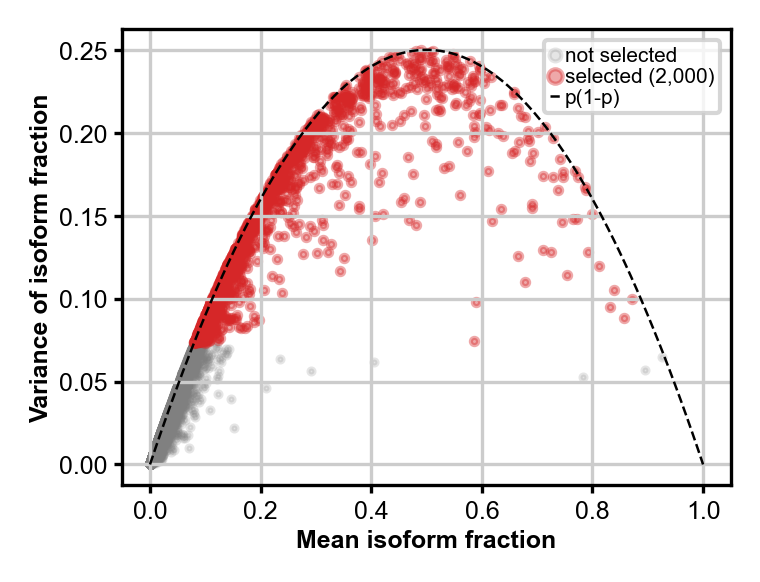

In [9]:
# Diagnostic: where the selected isoforms sit in the mean-variance plane. Method-agnostic --
# it describes the fraction matrix itself, not the selector. The p(1-p) curve is the variance
# a Bernoulli/binomial sample would have at that mean, shown as an orientation line only.
sel = np.zeros(adata.n_vars, dtype=bool); sel[hvf_idx] = True
mu_all = np.asarray(frac_csc.mean(axis=0)).ravel()
sq = frac_csc.multiply(frac_csc) if issparse(frac_csc) else frac_csc ** 2
var_all = np.asarray(sq.mean(axis=0)).ravel() - mu_all ** 2

fig, ax = plt.subplots(figsize=(2.6, 2.0))
ax.scatter(mu_all[~sel], var_all[~sel], s=2, alpha=0.2, color="grey", label="not selected")
ax.scatter(mu_all[sel], var_all[sel], s=3, alpha=0.4, color="tab:red",
           label=f"selected ({int(sel.sum()):,})")
_mm = np.linspace(0, 1, 100)
ax.plot(_mm, _mm * (1 - _mm), "k--", lw=0.6, label="p(1-p)")
ax.set_xlabel("Mean isoform fraction")
ax.set_ylabel("Variance of isoform fraction")
ax.legend(markerscale=2, fontsize=5)
fig.savefig(figpath("04_10_hvf_selection_diagnostics.pdf"), bbox_inches="tight")
plt.show()

## 2. PCA + UMAP on highly variable isoforms

In [25]:
adata

AnnData object with n_obs × n_vars = 203311 × 478192
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'tube_id', 'n_counts', 'donor', 'tissue', 'tube_label', 'LR_library_id', 'SR_sample_id', 'popv_prediction', 'popv_prediction_score', 'cell_ontology_class', 'broad_cell_class'
    var: 'transcript_id', 'gene_name', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'tissue_colors', 'broad_cell_class_colors', 'donor_colors', 'tube_id_colors'
    obsm: 'X_pca_hvf', 'X_pca_hvf_harmony', 'X_umap'
    layers: 'isoform_fraction'

In [33]:
# Build AnnData on the selected isoforms (X = isoform fraction) and run PCA
#
# --- BATCH INTEGRATION ------------------------------------------------------------------
# HARMONY_BATCH names the obs column Harmony corrects on, or None to skip integration and
# reproduce the original embedding exactly. tube_id is the finest batch unit available: one
# 10x library, so it absorbs library-prep and sequencing-run effects that `donor` alone
# cannot. Note it is partly confounded with tissue (most tubes are one tissue), so Harmony
# will remove some genuine tissue signal along with the technical variation -- compare the
# tissue-coloured UMAP before and after before trusting it.

HARMONY_BATCH = None       # None -> no integration
EMB_SUFFIX = "" if HARMONY_BATCH is None else "_harmony"
hvf_mask = np.zeros(adata.n_vars, dtype=bool); hvf_mask[hvf_idx] = True
adata_hvf = adata[:, hvf_mask].copy()
adata_hvf.X = csr_matrix(adata_hvf.layers["isoform_fraction"])
n_pcs = min(50, adata_hvf.n_vars - 1)
sc.tl.pca(adata_hvf, n_comps=n_pcs, svd_solver="arpack")
print(f"HVF AnnData: {adata_hvf.shape} | PCA {n_pcs} PCs, "
      f"variance explained {adata_hvf.uns['pca']['variance_ratio'].sum():.1%}")

HVF AnnData: (203311, 2000) | PCA 50 PCs, variance explained 23.9%


In [34]:
# Harmony batch integration on the HVF PCA. Writes adata_hvf.obsm["X_pca_harmony"];
# the neighbour graph below uses it when it exists and falls back to plain PCA otherwise.
USE_REP = "X_pca"
if HARMONY_BATCH is not None:
    if HARMONY_BATCH not in adata_hvf.obs.columns:
        raise KeyError(f"{HARMONY_BATCH!r} is not in adata_hvf.obs. Available: "
                       f"{sorted(adata_hvf.obs.columns)[:25]}")
    _b = adata_hvf.obs[HARMONY_BATCH].astype(str)
    print(f"Harmony batch key {HARMONY_BATCH!r}: {_b.nunique()} levels, "
          f"{_b.value_counts().min():,}-{_b.value_counts().max():,} cells each")
    # Harmony needs the batch as a category with no unused levels, and it must not be numeric.
    adata_hvf.obs[HARMONY_BATCH] = _b.astype("category")
    # harmonypy is called DIRECTLY rather than through scanpy.external.pp.harmony_integrate.
    # That wrapper does `adata.obsm[basis] = harmony_out.Z_corr.T`, which was right when
    # Z_corr was (n_pcs, n_cells). harmonypy 0.2.0 (the PyTorch rewrite) already returns
    # Z_corr as (n_cells, n_pcs), so the wrapper transposes a second time and anndata
    # rejects the result with "Value had shape (50,) ... should have had (203311,)".
    # Assigning it here with an explicit orientation check works under either convention.
    try:
        import harmonypy
    except ImportError as e:
        raise ImportError(
            "harmonypy is required for Harmony integration. Install it into this kernel "
            "(`pip install harmonypy`) or set HARMONY_BATCH = None to skip integration."
        ) from e

    _ho = harmonypy.run_harmony(adata_hvf.obsm["X_pca"].astype(np.float64),
                                adata_hvf.obs, HARMONY_BATCH)
    _Z = np.asarray(_ho.Z_corr)
    _want = (adata_hvf.n_obs, adata_hvf.obsm["X_pca"].shape[1])
    if _Z.shape == _want:
        pass                                  # harmonypy >= 0.2: already (cells, PCs)
    elif _Z.shape == _want[::-1]:
        _Z = _Z.T                             # harmonypy < 0.2: (PCs, cells)
    else:
        raise ValueError(f"Harmony returned {_Z.shape}, expected {_want} or {_want[::-1]}")
    adata_hvf.obsm["X_pca_harmony"] = np.ascontiguousarray(_Z, dtype=np.float32)
    USE_REP = "X_pca_harmony"
    _d = np.abs(adata_hvf.obsm["X_pca_harmony"] - adata_hvf.obsm["X_pca"])
    print(f"Harmony done -> obsm['X_pca_harmony'] {adata_hvf.obsm['X_pca_harmony'].shape}; "
          f"mean |shift| per cell {_d.mean():.4f} (PC units)")
else:
    print("HARMONY_BATCH is None -- no integration, embedding is the plain HVF PCA")
print(f"neighbour graph will use: {USE_REP}")

HARMONY_BATCH is None -- no integration, embedding is the plain HVF PCA
neighbour graph will use: X_pca


In [35]:
# Neighbors + UMAP on the highly variable isoform features
sc.pp.neighbors(adata_hvf, n_pcs=n_pcs, n_neighbors=30, use_rep=USE_REP)
sc.tl.umap(adata_hvf)
adata.obsm["X_pca_hvf"] = adata_hvf.obsm["X_pca"]
if USE_REP == "X_pca_harmony":
    adata.obsm["X_pca_hvf_harmony"] = adata_hvf.obsm["X_pca_harmony"]
adata.obsm["X_umap"] = adata_hvf.obsm["X_umap"]
print(f"UMAP computed on {USE_REP}")

UMAP computed on X_pca


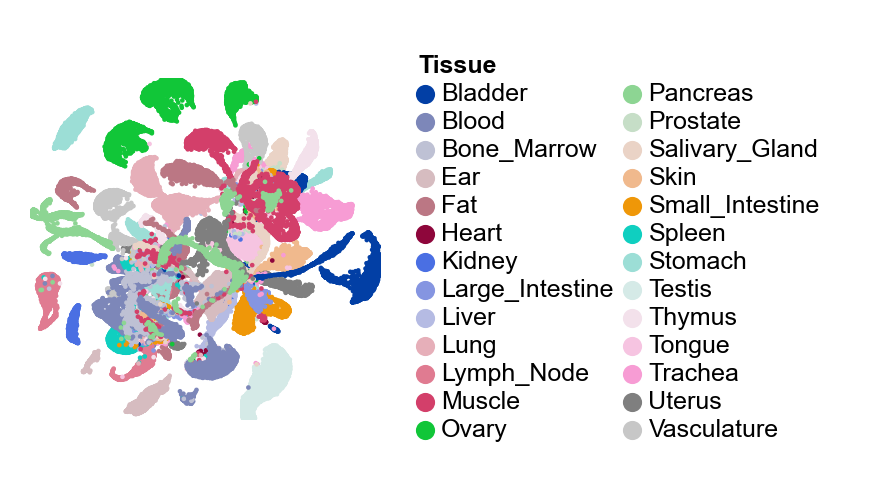

In [36]:
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(figsize=(1.5, 1.5)); plt.margins(x=0, y=0)
sc.pl.umap(adata, color=['tissue'], size=5, legend_fontsize=6, sort_order=True, frameon=False,
           title="", na_in_legend=False, show=False, ax=ax)
plt.legend(ncol=2, prop={'size': 6}, handletextpad=0.4, markerscale=0.6, frameon=False, borderpad=1,
           columnspacing=0.5, labelspacing=0.2, loc=6, bbox_to_anchor=(1.0, 0.5), title="Tissue",
           alignment="left", title_fontproperties={'weight': 'bold', 'size': 6})
plt.savefig(figpath(f"04_10_umap_hv_isoforms_tissue{EMB_SUFFIX}.pdf"))
plt.show()

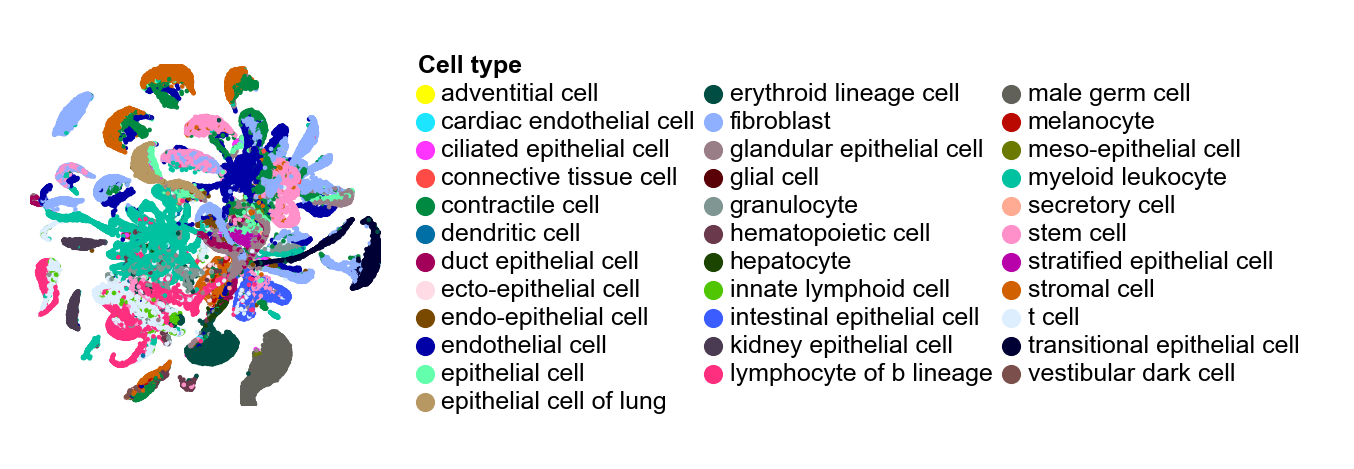

In [37]:
fig, ax = plt.subplots(figsize=(1.5, 1.5)); plt.margins(x=0, y=0)
sc.pl.umap(adata, color=['broad_cell_class'], size=5, legend_fontsize=6, sort_order=True, frameon=False,
           title="", na_in_legend=False, show=False, ax=ax)
plt.legend(ncol=3, prop={'size': 6}, handletextpad=0.4, markerscale=0.6, frameon=False, borderpad=1,
           columnspacing=0.5, labelspacing=0.2, loc=6, bbox_to_anchor=(1.0, 0.5), title="Cell type",
           alignment="left", title_fontproperties={'weight': 'bold', 'size': 6})
plt.savefig(figpath(f"04_10_umap_hv_isoforms_celltype{EMB_SUFFIX}.pdf"))
plt.show()

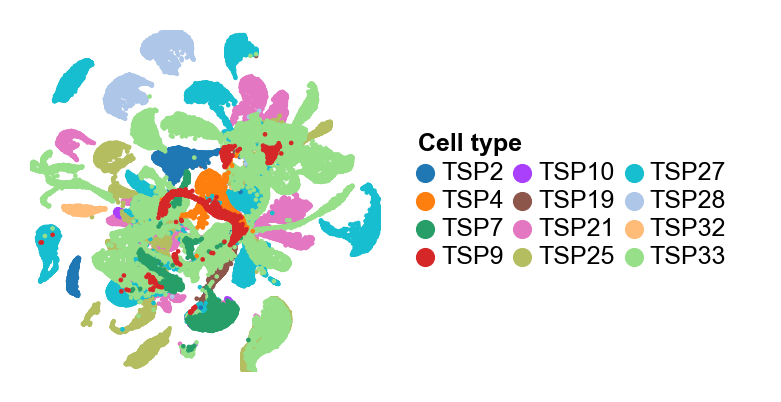

In [38]:
fig, ax = plt.subplots(figsize=(1.5, 1.5)); plt.margins(x=0, y=0)
sc.pl.umap(adata, color=['donor'], size=5, legend_fontsize=6, sort_order=True, frameon=False,
           title="", na_in_legend=False, show=False, ax=ax)
plt.legend(ncol=3, prop={'size': 6}, handletextpad=0.4, markerscale=0.6, frameon=False, borderpad=1,
           columnspacing=0.5, labelspacing=0.2, loc=6, bbox_to_anchor=(1.0, 0.5), title="Cell type",
           alignment="left", title_fontproperties={'weight': 'bold', 'size': 6})
plt.savefig(figpath(f"04_10_umap_hv_isoforms_donor{EMB_SUFFIX}.pdf"))
plt.show()

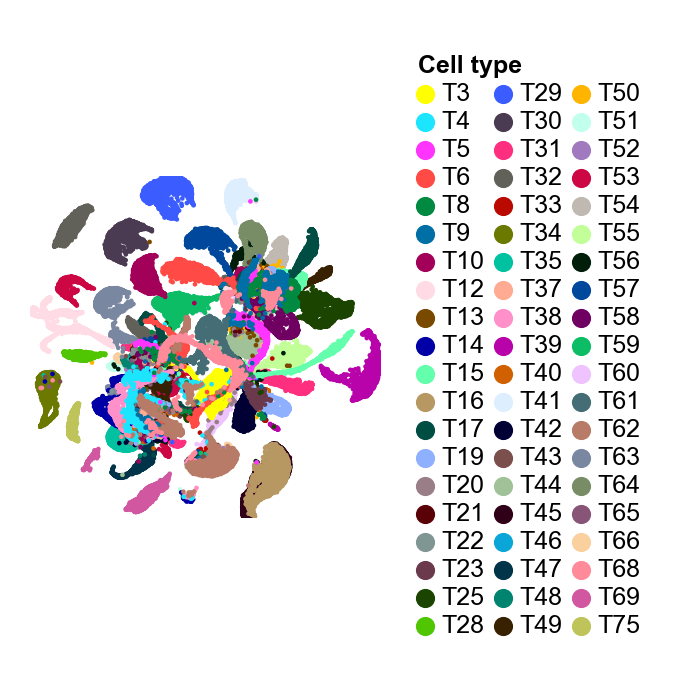

In [39]:
fig, ax = plt.subplots(figsize=(1.5, 1.5)); plt.margins(x=0, y=0)
sc.pl.umap(adata, color=['tube_id'], size=5, legend_fontsize=6, sort_order=True, frameon=False,
           title="", na_in_legend=False, show=False, ax=ax)
plt.legend(ncol=3, prop={'size': 6}, handletextpad=0.4, markerscale=0.6, frameon=False, borderpad=1,
           columnspacing=0.5, labelspacing=0.2, loc=6, bbox_to_anchor=(1.0, 0.5), title="Cell type",
           alignment="left", title_fontproperties={'weight': 'bold', 'size': 6})
plt.savefig(figpath(f"04_10_umap_hv_isoforms_tubeid{EMB_SUFFIX}.pdf"))
plt.show()